In [1]:
import os
from openai import OpenAI
import base64
from io import BytesIO
from IPython.display import HTML, display
from PIL import Image, ImageDraw, ImageFont
import io
import cv2
import numpy as np
from pydantic import BaseModel
from typing import Tuple, List


In [2]:
def convert_to_base64(img):
    """
    Convert PIL images to Base64 encoded strings

    :param pil_image: PIL image
    :return: Re-sized Base64 string
    """

    buffered = BytesIO()
    img.save(buffered, format="PNG")  # You can change the format if needed
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


def draw_axes_opencv(img, font_scale, grid_size=(4, 4)):
    """
    Draw axes and cell numbers with contours on an image using OpenCV.

    :param img: PIL image
    :param grid_size: Tuple indicating (rows, cols) of the grid
    :return: PIL image with axes and cell numbers
    """
    
    # Convert PIL image to NumPy array (for OpenCV)
    img_cv = np.array(img)
    
    # If image has alpha channel, convert it to BGR
    if img_cv.shape[2] == 4:
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGBA2RGB)
    
    height, width, _ = img_cv.shape
    
    # Calculate cell size based on the grid size
    rows, cols = grid_size
    cell_width = width // cols
    cell_height = height // rows
    
    # Define grid line color and thickness
    grid_color = (255, 0, 0)  # Blue in BGR
    grid_thickness = 2
    
    # Draw the vertical grid lines
    for i in range(1, cols):
        x = i * cell_width
        cv2.line(img_cv, (x, 0), (x, height), grid_color, grid_thickness)
    
    # Draw the horizontal grid lines
    for i in range(1, rows):
        y = i * cell_height
        cv2.line(img_cv, (0, y), (width, y), grid_color, grid_thickness)
    
    # Define text properties
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_color = (255, 255, 255)  # Red in BGR
    contour_color = (0, 0, 0)  # White contour for better visibility
    font_scale = min(cell_width, cell_height) / 100
    if width > 400:
        font_thickness = 2  # Thickness for the fill text
        contour_thickness = 6
    else:
        font_thickness = 1
        contour_thickness = 4  # Thickness for the contour
    text_offset_x = cell_width // 2
    text_offset_y = cell_height // 2
    
    # Iterate over each cell to place the cell number
    cell_number = 1
    for row in range(rows):
        for col in range(cols):
            # Calculate the center position of the cell
            center_x = col * cell_width + text_offset_x
            center_y = row * cell_height + text_offset_y
            
            # Get the text
            text = str(cell_number)
            
            # Get the text size to center it properly
            (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
            
            # Calculate the bottom-left corner of the text
            text_x = center_x - text_width // 2
            text_y = center_y + text_height // 2
            
            # Draw contour (outline) by drawing the text in contour color with higher thickness
            cv2.putText(img_cv, text, (text_x, text_y), font, font_scale, contour_color, contour_thickness, cv2.LINE_AA)
            
            # Draw the text in the fill color with lower thickness
            cv2.putText(img_cv, text, (text_x, text_y), font, font_scale, font_color, font_thickness, cv2.LINE_AA)
            
            cell_number += 1
    
    # Convert back to PIL image
    return Image.fromarray(img_cv)

def add_white_contour_opencv(img, font_scale=2):
    """
    Add a white background and labels to an image using OpenCV
    """
    # Convert PIL image to NumPy array (for OpenCV)
    img_cv = np.array(img)
    height, width, _ = img_cv.shape
    # Add padding for the white contour
    size = int(width * 0.11)
    new_img = np.full((height + size, width + size, 3), (255, 255, 255), dtype=np.uint8)
    new_img[size:, size:] = img_cv
    
    # Add the label using OpenCV
    cv2.putText(new_img, "(0, 0)", (int(size*0.2), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height//4}", (int(size*0.4), height//4+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height}", (int(size*0.4), height+int(size*0.9)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height//2}", (int(size*0.4), height//2+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{(height//2)+(height//4)}", (int(size*0.4), (height//2)+(height//4)+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)

    cv2.putText(new_img, f"{width}", (width+int(size*0.4), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{width//4}", (width//4+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{width//2}", (width//2+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{(width//4)+(width//2)}", ((width//4)+(width//2)+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    # Convert back to PIL image
    return Image.fromarray(new_img)

def pre_process_image_opencv(img, boxes, font_scale=0.0007):
    """
    Pre-process an image before displaying it with OpenCV

    :param img: PIL image
    :return: PIL image with axes, quadrants, and white contour
    """
    font_scale = img.size[0] * font_scale
    img = draw_axes_opencv(img, font_scale)
    if boxes:
        img = draw_bounding_boxes(img, boxes)
    #img = add_white_contour_opencv(img, font_scale)
    return img

def reduce_image_size(image, max_size=500):
    """
    Reduce the size of an image while maintaining the aspect ratio

    :param image: PIL image
    :param max_size: Maximum size for the image
    :return: Resized PIL image
    """
    width, height = image.size
    if width > height:
        new_width = max_size
        new_height = int(max_size * height / width)
    else:
        new_height = max_size
        new_width = int(max_size * width / height)
    return image.resize((new_width, new_height))

def reduce_resolution(image, resample_filter=Image.NEAREST):
    """
    Lower the resolution of the image by applying a resample filter.
    :param image: PIL image
    :param resample_filter: Resampling filter to use (default: Image.NEAREST for lower quality)
    :return: Lower resolution PIL image
    """
    # Applying the selected filter for downsampling
    width, height = image.size
    return image.resize((width, height), resample=resample_filter)

def process(image, reduce_resolution=False, reduce_size=True, boxes=None):
    
    image = pre_process_image_opencv(image, boxes)

    if reduce_size:
        image = reduce_image_size(image)
    if reduce_resolution:
        image = reduce_resolution(image)
        
    image_base64 = convert_to_base64(image)
    return image_base64

def save_img(image, path):
    image.save(path)

def draw_bounding_boxes(image, boxes):
    """
    Draws bounding boxes on an image.

    :param image: PIL image object
    :param boxes: List of tuples, each tuple containing (x1, y1, x2, y2) 
                  which represent the top-left and bottom-right corners of a box
    :return: Image with bounding boxes drawn
    """
    
    # Create a drawing context
    image_copy = image.copy()
    draw = ImageDraw.Draw(image_copy)
    
    # Loop through each box in the list
    for box in boxes:
        x1, y1, x2, y2 = box
        
        # Draw rectangle with a red outline (you can adjust color and width)
        draw.rectangle([x1, y1, x2, y2], outline="green", width=4)
    
    return image_copy

def plt_image(image):
    display(HTML(f'<img src="data:image/png;base64,{image}">'))

def get_cells(response):
    return [response.cell_numbers[0].top, response.cell_numbers[0].bottom, response.cell_numbers[0].left, response.cell_numbers[0].right]

def calculate_box_from_crops(image, cells):
    """
    Calculate the bounding box based on the cell numbers provided.

    :param cells: List of cell numbers [top, bottom, left, right]
    :param cells_2: List of cell numbers [top, bottom, left, right]
    :param cells_3: List of cell numbers [top, bottom, left, right]
    :return: List of tuples, each tuple containing (x1, y1, x2, y2) 
             which represent the top-left and bottom-right corners of a box
    """
    # Define the cell size based on the grid size
    rows, cols = 4, 4  # Assuming the grid is 4x4
    width, height = image.size

    left_pixels, top_pixels, right_pixels, bottom_pixels = 0, 0, width, height

    for i in range(len(cells)):
        cell_width = width // cols
        cell_height = height // rows

        cell_top, cell_bottom, cell_left, cell_right = cells[i]

        left = ((cell_left - 1) % cols) * cell_width
        top = ((cell_top - 1) // cols) * cell_height
        right = ((cell_right - 1) % cols + 1) * cell_width  
        bottom = ((cell_bottom - 1) // cols + 1) * cell_height  

        left_pixels += left
        top_pixels += top
        right_pixels -= (width - right)
        bottom_pixels -= (height - bottom)

        width = right - left
        height = bottom - top
    #print(left_pixels, top_pixels, right_pixels, bottom_pixels)
    # draw the bounding boxes
    boxes = [(left_pixels, top_pixels, right_pixels, bottom_pixels)]
    return boxes

def crop_image(image, cells):
    """
    Crop an image based on the cell numbers provided.

    :param image: PIL image
    :param cells: List of cell numbers [top, bottom, left, right]
    :return: Cropped PIL image
    """
    cell_top, cell_bottom, cell_left, cell_right = cells

    # Define the cell size based on the grid size
    rows, cols = 4, 4  # Assuming the grid is 4x4
    cell_width = image.size[0] // cols
    cell_height = image.size[1] // rows

    # Compute the bounding box (left, upper, right, lower) in pixels
    left = ((cell_left - 1) % cols) * cell_width
    top = ((cell_top - 1) // cols) * cell_height
    right = ((cell_right - 1) % cols + 1) * cell_width  # Ensure the entire right cell is included
    bottom = ((cell_bottom - 1) // cols + 1) * cell_height  # Ensure the entire bottom cell is included

    # Crop the image
    cropped_img = image.crop((left, top, right, bottom))
    # Return the cropped image
    return cropped_img

In [3]:
#image_path = 'test.png'
example_path = 'Zidane from Ultralytics.jpg'
example = Image.open(example_path)

In [4]:
image_path = 'person_3.jpg'
image = Image.open(image_path)


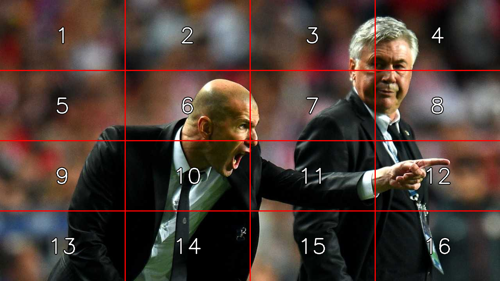


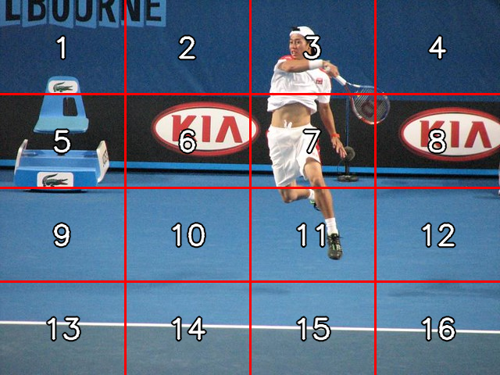

In [5]:
plt_image(process(example))
plt_image(process(image))

In [6]:
image_processed = process(image)
example_processed = process(example)

In [7]:
class BoundingBox(BaseModel):
    label: str
    top_left: list[int]  
    bottom_right: list[int]

class Detection(BaseModel):
    bounding_boxes: list[BoundingBox]

class CellNumbers(BaseModel):
    top: int
    bottom: int
    left: int
    right: int

class ResponseCellNumbers(BaseModel):
    cell_numbers: list[CellNumbers]
    done: bool

# Function to ask LLM to detect UI elements and return bounding boxes
def ask_llm_to_detect_ui(client, example, image, overlayed_image, image_size, max_tokens=500):
    response = client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": [
                                    {
                                    "type": "text",
                                    "text": """
                                            You are a computer vision model that detects objects in images. 
                                            The image has a 4x4 grid overlay with numbered cells, starting from cell 1 at the top-left corner
                                            and ending with cell 16 at the bottom-right corner. The cells are numbered increasing left to right 
                                            and top to bottom. For each object, provide the cell numbers corresponding 
                                            to the top, bottom, left, and right edges of the object. Ensure you reference the cell numbers as 
                                            they appear on the grid overlay in the image. If all the rows and all the columns contain a part of the object, 
                                            then return true for the 'done' variable and false if there are still rows or columns that don't contain 
                                            any part of the object.
                                            """,
                                    },

                ]},
            {
            "role": "user",
            "content": [
                {
                "type": "text",
                "text": f"Detect the people in this image of size {image_size}. Here you have the original image for your reference and the image with the grid cells:",
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image}",
                },
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{overlayed_image}",
                },
                },
                                {
                "type": "text",
                "text": """
                        Here you have an example of how to do this: you are asked to detect the people in the image below:  
                        """,
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{example}",
                },
                },
                {
                "type": "text",
                "text": """
                        Then your response would be, for the person on the left, cell 6 (because that is the highest 
                        cell that contains the person), cell 14 (because that is the lowest cell that contains the person),
                        cell 13 (because that is the leftmost cell that contains the person), and cell 12 (because that is the 
                        rightmost cell that contains the person). 
                        For the person on the right, it would be cell 4 (top cell), cell 16 (lowest cell), cell 15 (leftmost cell), and cell 16 (rightmost cell).
                        Note that the cells could repeat. For example, if the person is in a single cell, all four cell numbers would be the same.
                        """,
                },
            ],
            }
        ],
        max_tokens=max_tokens,
        response_format=ResponseCellNumbers,
        )
    #print(response)
    return response.choices[0].message.parsed


In [8]:
# Main process
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])



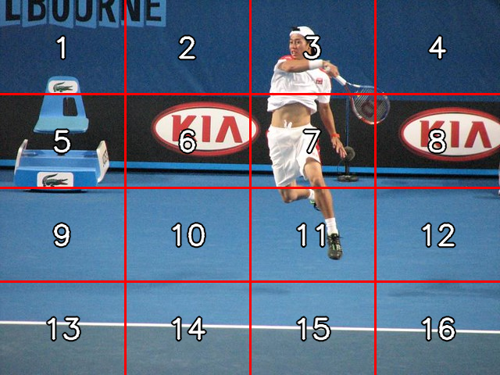

Iteration 0



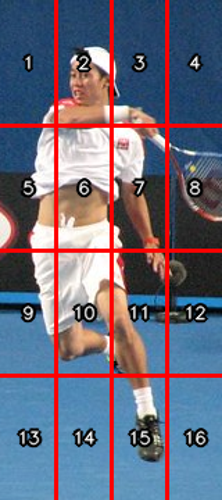

Iteration 1



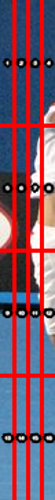

Iteration 2



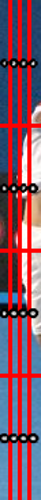

Iteration 3



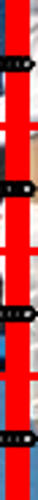

Iteration 4


Iteration 5


KeyboardInterrupt: 

In [10]:
image_ = image
cells = []
complete = [1, 4, 13, 16]
plt_image(image_processed)
done = False
i = 0
while not done:
    print(f"Iteration {i}")
    response = ask_llm_to_detect_ui(client, example_processed, convert_to_base64(reduce_image_size(image_)), image_processed, image_.size)
    if set(get_cells(response)) == set(complete):
        break
    cells.append(get_cells(response))
    image_ = crop_image(image_, cells[i])
    image_processed = process(image_)
    plt_image(image_processed)
    done = response.done
    i += 1

boxes = calculate_box_from_crops(image, cells)
img = draw_bounding_boxes(image, boxes)
save_img(img, "detected_3_1.jpg")
img

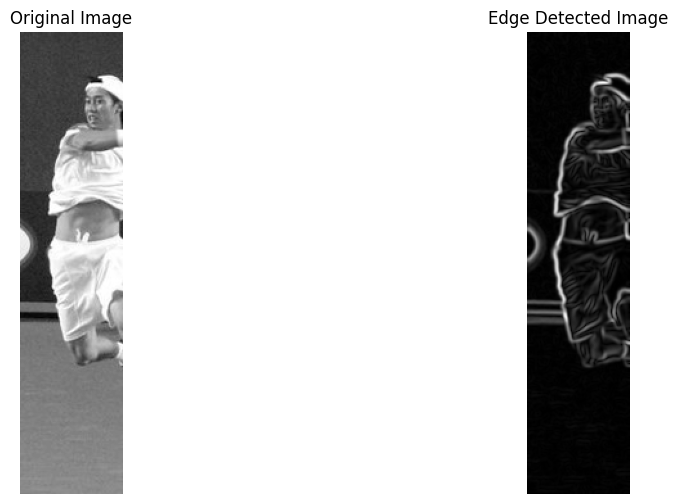

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

def edge_detection(image):
    # Read the image in grayscale
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    
    # Check if the image was successfully loaded
    if img is None:
        print('Error: Image not found or unable to load.')
        return
    
    # Apply Gaussian Blur to reduce noise
    blurred_img = cv2.GaussianBlur(img, (3, 3), 0)
    
    # Compute gradients along the X and Y axis using the Sobel operator
    grad_x = cv2.Sobel(blurred_img, cv2.CV_64F, 1, 0, ksize=5)
    grad_y = cv2.Sobel(blurred_img, cv2.CV_64F, 0, 1, ksize=5)
    
    # Calculate the magnitude of the gradients
    magnitude = cv2.magnitude(grad_x, grad_y)
    
    # Normalize the magnitude to the range [0, 255] and convert to uint8
    normalized_magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    edge_image = np.uint8(normalized_magnitude)
    
    # Display the original and edge-detected images side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(edge_image, cmap='gray')
    plt.title('Edge Detected Image')
    plt.axis('off')
    plt.show()
    
    # Optionally, save the edge-detected image
    # cv2.imwrite('edge_detected.png', edge_image)

# Example usage
edge_detection(image_)